In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [2]:
df = pd.read_csv("nba_preprocessed.csv")

print(df.head())
print(df.info())

print("Dataset loaded successfully")

   Game_Date  Team  Player        MP       PTS       TRB       AST       FGA  \
0   20251101    25     113  1.830533  2.048740 -0.015845  0.208047  1.805808   
1   20251101    25     494  1.582544  2.273030 -0.015845 -0.177476  1.470112   
2   20251101    25     117  1.418808  1.488015  0.283463  1.750142  0.798719   
3   20251101    25     127  1.404501  1.488015  2.677930  1.364618  0.798719   
4   20251101    25     143 -1.636546 -0.979176 -0.913770 -0.948523 -1.215461   

        FG%      STL       TOV  
0  0.293646 -0.78218  0.508793  
1  0.059664  0.22981 -0.910007  
2  0.672273  1.24180  1.218193  
3  0.672273  0.22981  1.218193  
4  2.310152 -0.78218 -0.910007  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9067 entries, 0 to 9066
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Game_Date  9067 non-null   int64  
 1   Team       9067 non-null   int64  
 2   Player     9067 non-null   int64  
 3   MP       

In [3]:
X = df.drop("PTS", axis=1)

y = df["PTS"]

print("Features and target selected successfully")

Features and target selected successfully


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data split completed successfully")

Data split completed successfully


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline: scale features, then apply SVR
svm_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=10, epsilon=0.1)
)

print("SVM model with scaling created successfully")


SVM model with scaling created successfully


In [6]:
svm_model.fit(X_train, y_train)
print("SVM model trained successfully")


SVM model trained successfully


In [7]:
y_pred = svm_model.predict(X_test)

print("Prediction completed successfully")

Prediction completed successfully


In [8]:
print("SVM Model Evaluation")
print("----------------------")

print("Model: Support Vector Regression")
print("Target Variable: PTS")

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

SVM Model Evaluation
----------------------
Model: Support Vector Regression
Target Variable: PTS
Mean Absolute Error: 0.19149065064779594
R2 Score: 0.9238201910400798


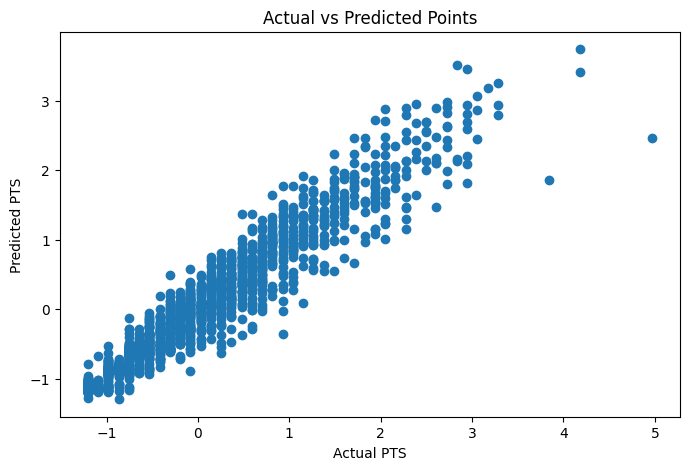

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual PTS")
plt.ylabel("Predicted PTS")

plt.title("Actual vs Predicted Points")

plt.show()

In [10]:
joblib.dump(svm_model, "svm_pts_model.pkl")

print("SVM model saved successfully")

SVM model saved successfully


In [11]:
print("""
Support Vector Regression (SVR) was used to predict NBA player points (PTS).
The model learns patterns between player statistics and points scored.
The model performance was evaluated using MAE and R2 Score.
""")


Support Vector Regression (SVR) was used to predict NBA player points (PTS).
The model learns patterns between player statistics and points scored.
The model performance was evaluated using MAE and R2 Score.

